# 03 · Regression Deep Dive: normal equation, GD stability, conditioning, ridge/lasso, diagnostics, CV

Companion notebook for `03-Supervised-Learning-Regression.md` (Sections 20–27). The original notebook `03_linear_regression.ipynb` covers the basics; this one checks the deeper theory numerically.

| Part | What |
|---|---|
| A | Normal equation vs `np.linalg.lstsq` vs pseudo-inverse vs scikit-learn; projection geometry (residual ⟂ columns) |
| B | GD stability: the largest stable learning rate 2/L from eigenvalues; divergence just above it |
| C | Condition number before/after standardisation and its effect on GD iteration count |
| D | Ridge: closed form vs sklearn, fixing a singular XᵀX; ridge and lasso coefficient paths (diabetes) |
| E | Residual diagnostics on California housing |
| F | Cross-validated polynomial degree selection |
| G | Bias–variance decomposition by simulation |
| H | Checks of every hand-worked example in the note |
| I | Case study: food-delivery time (synthetic, Swiggy/Zomato-style features) |
| J | Case study: electricity demand with degree-day features (synthetic) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, lasso_path
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from scipy import stats
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## Part A — Four ways to solve least squares
The normal equation solves $`X^\top X\,\mathbf{w} = X^\top\mathbf{y}`$. In code, prefer `np.linalg.solve` (or `lstsq`, which uses an SVD) over forming the inverse.

In [2]:
Xd, yd = load_diabetes(return_X_y=True)          # 442 patients, 10 (already scaled) features
A = np.c_[np.ones(len(Xd)), Xd]                  # add the column of 1s

w_normal = np.linalg.solve(A.T @ A, A.T @ yd)    # normal equation
w_lstsq  = np.linalg.lstsq(A, yd, rcond=None)[0] # SVD-based least squares
w_pinv   = np.linalg.pinv(A) @ yd                # Moore-Penrose pseudo-inverse
sk = LinearRegression().fit(Xd, yd)
w_sk = np.r_[sk.intercept_, sk.coef_]

print("normal eq :", w_normal.round(2))
print("lstsq     :", w_lstsq.round(2))
print("pinv      :", w_pinv.round(2))
print("sklearn   :", w_sk.round(2))
print("max |difference| between all four:",
      max(np.abs(w_normal - w).max() for w in (w_lstsq, w_pinv, w_sk)))

normal eq : [ 152.13  -10.01 -239.82  519.85  324.38 -792.18  476.74  101.04  177.06
  751.27   67.63]
lstsq     : [ 152.13  -10.01 -239.82  519.85  324.38 -792.18  476.74  101.04  177.06
  751.27   67.63]
pinv      : [ 152.13  -10.01 -239.82  519.85  324.38 -792.18  476.74  101.04  177.06
  751.27   67.63]
sklearn   : [ 152.13  -10.01 -239.82  519.85  324.38 -792.18  476.74  101.04  177.06
  751.27   67.63]
max |difference| between all four: 2.3987922759260982e-11


In [3]:
# Geometry: the residual is orthogonal to every column of X, so X^T e = 0
e = yd - A @ w_normal
print("X^T e (should be ~0):", (A.T @ e).round(8)[:5], "...")
print("sum of residuals     :", round(e.sum(), 8), " (zero because of the intercept column)")
# Hat matrix H = X (X^T X)^{-1} X^T is a projection: symmetric, idempotent, trace = number of parameters
H = A @ np.linalg.solve(A.T @ A, A.T)
print("H symmetric:", np.allclose(H, H.T), "| H idempotent:", np.allclose(H @ H, H), "| trace(H) =", round(np.trace(H), 6))
# Pythagoras: SST = SSR + SSE
yhat = A @ w_normal
SST, SSR, SSE = ((yd - yd.mean())**2).sum(), ((yhat - yd.mean())**2).sum(), (e**2).sum()
print(f"SST = {SST:.1f}, SSR + SSE = {SSR + SSE:.1f}, R^2 = {1 - SSE/SST:.4f}")

X^T e (should be ~0): [-0.  0. -0. -0. -0.] ...
sum of residuals     : -0.0  (zero because of the intercept column)
H symmetric: True | H idempotent: True | trace(H) = 11.0
SST = 2621009.1, SSR + SSE = 2621009.1, R^2 = 0.5177


In [4]:
# Singular X^T X: a duplicated feature (experience in months and in years)
months = rng.uniform(0, 120, 50)
Xs = np.c_[np.ones(50), months, months / 12]
ys = 20000 + 300 * months + rng.normal(0, 2000, 50)
print("rank of X^T X:", np.linalg.matrix_rank(Xs.T @ Xs), "of", Xs.shape[1])
print("condition number of X^T X: %.2e" % np.linalg.cond(Xs.T @ Xs))
w_min_norm = np.linalg.lstsq(Xs, ys, rcond=None)[0]
print("lstsq (minimum-norm) solution:", w_min_norm.round(3))
print("effective slope per month = w1 + w2/12 =", round(w_min_norm[1] + w_min_norm[2] / 12, 3))

rank of X^T X: 2 of 3
condition number of X^T X: 5.23e+17
lstsq (minimum-norm) solution: [19514.942   306.594    25.549]
effective slope per month = w1 + w2/12 = 308.723


## Part B — How large can the learning rate be?
For the cost $`C(\mathbf{w}) = \frac{1}{2M}\lVert X\mathbf{w}-\mathbf{y}\rVert^2`$ the Hessian is $`H = X^\top X/M`$. GD converges iff $`0 < \alpha < 2/L`$ where $`L = \lambda_{\max}(H)`$.
Slide data: word count → votes.

H =
 [[ 1.   6.2]
 [ 6.2 40.6]]
eigenvalues: [ 0.052 41.548] | L = 41.548012 | 2/L = 0.048137 | kappa = 799.2
OLS solution (w0, w1): [-7.5926  2.7407]
alpha = 0.02407 (0.50 x 2/L): final cost after 300 its = 15.98
alpha = 0.04332 (0.90 x 2/L): final cost after 300 its = 15.63
alpha = 0.04766 (0.99 x 2/L): final cost after 300 its = 15.58
alpha = 0.04862 (1.01 x 2/L): final cost after 300 its = 7.325e+06
alpha = 0.05054 (1.05 x 2/L): final cost after 300 its = 3.47e+26


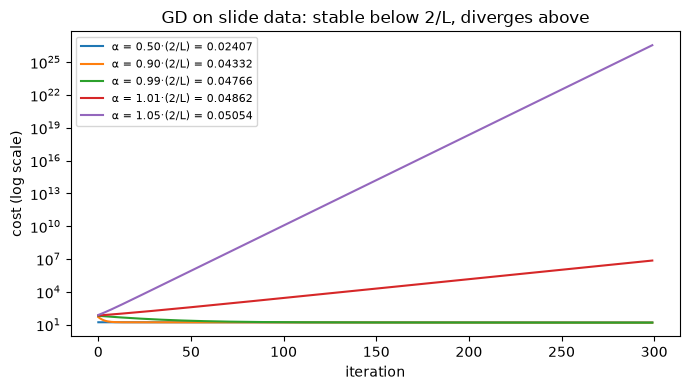

In [5]:
X = np.array([7, 8, 4, 7, 5], dtype=float)
Y = np.array([3, 15, 5, 20, 4], dtype=float)
A1 = np.c_[np.ones(5), X]
Hs = A1.T @ A1 / 5
lam = np.linalg.eigvalsh(Hs)
L = lam.max()
print("H =\n", Hs)
print("eigenvalues:", lam.round(6), "| L =", round(L, 6), "| 2/L =", round(2 / L, 6), "| kappa =", round(lam.max() / lam.min(), 1))
w_star = np.linalg.lstsq(A1, Y, rcond=None)[0]
print("OLS solution (w0, w1):", w_star.round(4))

def gd_costs(A, y, alpha, iters):
    w = np.zeros(A.shape[1]); costs = []
    for _ in range(iters):
        w = w - alpha * A.T @ (A @ w - y) / len(y)
        costs.append(np.mean((A @ w - y) ** 2) / 2)
    return w, np.array(costs)

fig, ax = plt.subplots(figsize=(7, 4))
for f in [0.5, 0.9, 0.99, 1.01, 1.05]:
    a = f * 2 / L
    w, cs = gd_costs(A1, Y, a, 300)
    ax.semilogy(cs, label=f"α = {f:.2f}·(2/L) = {a:.5f}")
    print(f"alpha = {a:.5f} ({f:.2f} x 2/L): final cost after 300 its = {cs[-1]:.4g}")
ax.set_xlabel("iteration"); ax.set_ylabel("cost (log scale)"); ax.set_title("GD on slide data: stable below 2/L, diverges above")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [6]:
# Theory: the error along eigenvector i is multiplied by (1 - alpha*lambda_i) every step.
for f in [0.5, 0.99, 1.01]:
    a = f * 2 / L
    print(f"alpha = {f:.2f}*(2/L): factors |1 - a*lambda| =", np.abs(1 - a * lam).round(5))
a_opt = 2 / (lam.min() + lam.max())
rate = (lam.max() / lam.min() - 1) / (lam.max() / lam.min() + 1)
print(f"optimal alpha = {a_opt:.5f}, contraction per step = {rate:.5f}, "
      f"steps to shrink the error by 1e-6 ≈ {np.log(1e-6) / np.log(rate):.0f}")

alpha = 0.50*(2/L): factors |1 - a*lambda| = [0.9988 0.    ]
alpha = 0.99*(2/L): factors |1 - a*lambda| = [0.9975 0.98  ]
alpha = 1.01*(2/L): factors |1 - a*lambda| = [0.9975 1.02  ]
optimal alpha = 0.04808, contraction per step = 0.99750, steps to shrink the error by 1e-6 ≈ 5521


## Part C — Conditioning and feature scaling
Iterations needed by GD grow roughly in proportion to the condition number $`\kappa = \lambda_{\max}/\lambda_{\min}`$ of $`H`$. Standardising features makes $`H`$ close to a correlation matrix.

In [7]:
def cond_H(Xraw):
    A = np.c_[np.ones(len(Xraw)), Xraw]
    return np.linalg.cond(A.T @ A / len(A))

def iters_to_converge(Xraw, y, tol=1e-6, max_it=200000):
    A = np.c_[np.ones(len(Xraw)), Xraw]
    H = A.T @ A / len(A)
    lam = np.linalg.eigvalsh(H)
    a = 2 / (lam.min() + lam.max())            # best fixed step for this H
    w_star = np.linalg.lstsq(A, y, rcond=None)[0]
    w = np.zeros(A.shape[1])
    for k in range(1, max_it + 1):
        w -= a * A.T @ (A @ w - y) / len(y)
        if np.linalg.norm(w - w_star) <= tol * np.linalg.norm(w_star):
            return k
    return f">{max_it}"

Zs = StandardScaler().fit_transform(X.reshape(-1, 1))
print("Slide data  : kappa raw = %.1f, standardised = %.1f" % (cond_H(X.reshape(-1, 1)), cond_H(Zs)))
print("              GD iterations raw =", iters_to_converge(X.reshape(-1, 1), Y), "| standardised =", iters_to_converge(Zs, Y))

cal = fetch_california_housing()
Xc, yc = cal.data, cal.target
Zc = StandardScaler().fit_transform(Xc)
print("California  : kappa raw = %.3g, standardised = %.1f" % (cond_H(Xc), cond_H(Zc)))
print("              GD iterations raw =", iters_to_converge(Xc, yc, max_it=20000), "| standardised =", iters_to_converge(Zc, yc))

Slide data  : kappa raw = 799.2, standardised = 1.0
              GD iterations raw = 5521 | standardised = 1
California  : kappa raw = 5.68e+10, standardised = 44.5


              GD iterations raw = >20000 | standardised = 272


## Part D — Ridge and lasso
Ridge closed form (intercept not penalised, so we centre first): $`\mathbf{w} = (X^\top X + \lambda I)^{-1}X^\top\mathbf{y}`$. scikit-learn's `Ridge(alpha=λ)` minimises $`\lVert \mathbf{y}-X\mathbf{w}\rVert^2 + \lambda\lVert \mathbf{w}\rVert^2`$, the same objective.

In [8]:
lam_r = 10.0
Xc_d = Xd - Xd.mean(0); yc_d = yd - yd.mean()
w_ridge = np.linalg.solve(Xc_d.T @ Xc_d + lam_r * np.eye(Xd.shape[1]), Xc_d.T @ yc_d)
w_ridge_sk = Ridge(alpha=lam_r).fit(Xd, yd).coef_
print("ridge closed form:", w_ridge.round(3))
print("sklearn Ridge    :", w_ridge_sk.round(3))
print("max |diff|       :", np.abs(w_ridge - w_ridge_sk).max())

# Ridge fixes a singular X^T X (the tiny collinear example from the note, Section 27)
Xt = np.array([[1, 2], [2, 4], [3, 6]], float); yt = np.array([2, 4, 7], float)
print("\ndet(X^T X) =", np.linalg.det(Xt.T @ Xt))
for l in [1, 10]:
    print(f"lambda = {l:>2}: w = {np.linalg.solve(Xt.T @ Xt + l * np.eye(2), Xt.T @ yt).round(4)}")
print("pinv (lambda -> 0 limit):", (np.linalg.pinv(Xt) @ yt).round(4))

ridge closed form: [ 19.813  -0.918  75.416  55.025  19.925  13.949 -47.554  48.259  70.144
  44.214]
sklearn Ridge    : [ 19.813  -0.918  75.416  55.025  19.925  13.949 -47.554  48.259  70.144
  44.214]
max |diff|       : 2.842170943040401e-14

det(X^T X) = 0.0
lambda =  1: w = [0.4366 0.8732]
lambda = 10: w = [0.3875 0.775 ]
pinv (lambda -> 0 limit): [0.4429 0.8857]


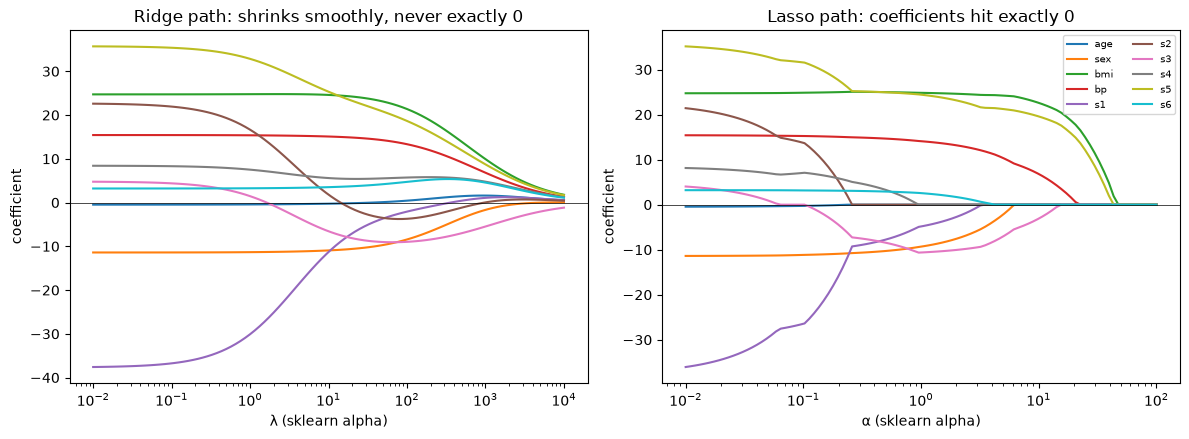

Lasso alpha =  0.1: 9 of 10 coefficients non-zero
Lasso alpha =    1: 7 of 10 coefficients non-zero
Lasso alpha =    5: 5 of 10 coefficients non-zero
Lasso alpha =   20: 3 of 10 coefficients non-zero


In [9]:
# Coefficient paths on the diabetes data (features standardised)
Zd = StandardScaler().fit_transform(Xd)
names = load_diabetes().feature_names
lams = np.logspace(-2, 4, 100)
ridge_coefs = np.array([Ridge(alpha=l).fit(Zd, yd).coef_ for l in lams])
alphas_l, lasso_coefs, _ = lasso_path(Zd, yd - yd.mean(), alphas=np.logspace(-2, 2, 100))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for j in range(Zd.shape[1]):
    axs[0].semilogx(lams, ridge_coefs[:, j], label=names[j])
    axs[1].semilogx(alphas_l, lasso_coefs[j], label=names[j])
axs[0].set_title("Ridge path: shrinks smoothly, never exactly 0"); axs[0].set_xlabel("λ (sklearn alpha)")
axs[1].set_title("Lasso path: coefficients hit exactly 0"); axs[1].set_xlabel("α (sklearn alpha)")
for a in axs: a.axhline(0, color="k", lw=0.5); a.set_ylabel("coefficient")
axs[1].legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

for a in [0.1, 1, 5, 20]:
    nz = (Lasso(alpha=a).fit(Zd, yd).coef_ != 0).sum()
    print(f"Lasso alpha = {a:>4}: {nz} of 10 coefficients non-zero")

## Part E — Residual diagnostics (California housing)

test R^2 = 0.576, RMSE = 0.746
share of targets at the 5.0 cap (USD 500k): 0.0481
predictions below 0 (impossible prices): 15


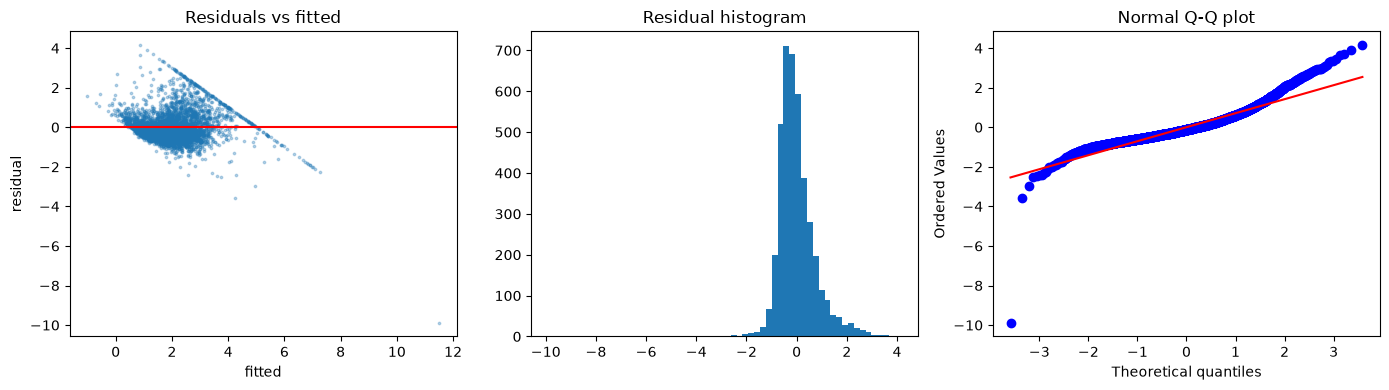

In [10]:
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2, random_state=42)
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr)
pred = pipe.predict(Xte); res = yte - pred
print("test R^2 = %.3f, RMSE = %.3f" % (1 - (res**2).sum() / ((yte - yte.mean())**2).sum(), np.sqrt((res**2).mean())))
print("share of targets at the 5.0 cap (USD 500k):", round((yc >= 5.0).mean(), 4))
print("predictions below 0 (impossible prices):", (pred < 0).sum())

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].scatter(pred, res, s=3, alpha=0.3); axs[0].axhline(0, color="r")
axs[0].set_xlabel("fitted"); axs[0].set_ylabel("residual"); axs[0].set_title("Residuals vs fitted")
axs[1].hist(res, bins=60); axs[1].set_title("Residual histogram")
stats.probplot(res, dist="norm", plot=axs[2]); axs[2].set_title("Normal Q-Q plot")
plt.tight_layout(); plt.show()

Reading the plots: the diagonal stripe in "residuals vs fitted" is the **capped target** (all houses ≥ USD 500k recorded as 5.0), the fan shape is **heteroscedasticity** (bigger errors for expensive districts), and the Q-Q tails show **heavy-tailed** errors. A log-target is one common fix for the fan:

In [11]:
pipe_log = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, np.log(ytr))
pred_log = np.exp(pipe_log.predict(Xte))
for name, p in [("raw target", pred), ("log target", pred_log)]:
    r = yte - p
    print(f"{name:>10}: RMSE = {np.sqrt((r**2).mean()):.3f}, MAE = {np.abs(r).mean():.3f}, negative predictions = {(p < 0).sum()}, median |error| = {np.median(np.abs(r)):.3f}, max prediction = {p.max():.2f}")

raw target: RMSE = 0.746, MAE = 0.533, negative predictions = 15, median |error| = 0.410, max prediction = 11.50
log target: RMSE = 1.531, MAE = 0.567, negative predictions = 0, median |error| = 0.350, max prediction = 78.50


## Part F — Choosing the polynomial degree by cross-validation

,train MSE,CV MSE,CV std
degree,,,
1,23.53,24.78,10.17
2,13.92,15.69,5.88
3,8.48,9.94,3.66
4,7.88,9.63,2.56
5,7.83,10.92,3.61
6,7.24,9.93,4.29
7,7.09,10.38,4.64
8,7.05,10.73,5.39
9,7.05,11.54,5.94


degree with lowest CV MSE: 4 (true degree = 3)


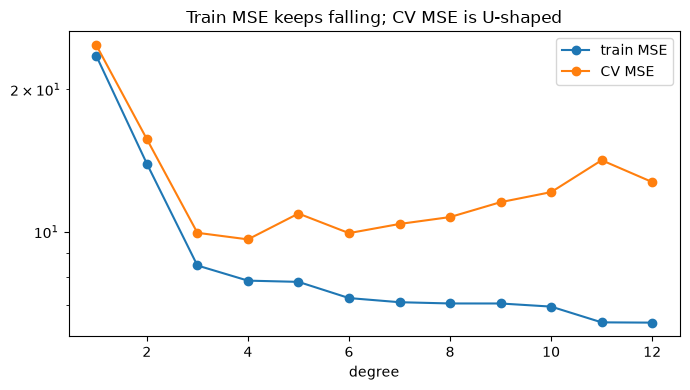

In [12]:
n = 60
x = np.sort(rng.uniform(-3, 3, n))
y = 0.5 * x**3 - x**2 + 2 * x + rng.normal(0, 3, n)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rows = []
for d in range(1, 13):
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), LinearRegression())
    cv_mse = -cross_val_score(model, x.reshape(-1, 1), y, cv=kf, scoring="neg_mean_squared_error")
    tr_mse = np.mean((model.fit(x.reshape(-1, 1), y).predict(x.reshape(-1, 1)) - y) ** 2)
    rows.append((d, tr_mse, cv_mse.mean(), cv_mse.std()))
cvdf = pd.DataFrame(rows, columns=["degree", "train MSE", "CV MSE", "CV std"]).set_index("degree")
display(cvdf.round(2))
best = cvdf["CV MSE"].idxmin()
print("degree with lowest CV MSE:", best, "(true degree = 3)")
ax = cvdf[["train MSE", "CV MSE"]].plot(marker="o", logy=True, figsize=(7, 4))
ax.set_title("Train MSE keeps falling; CV MSE is U-shaped"); plt.tight_layout(); plt.show()

## Part G — Bias² + variance + noise, by simulation
Draw 500 training sets from $`y = \sin(x) + \varepsilon`$, $`\sigma = 0.3`$, fit polynomials of degree 1, 3 and 12, and decompose the expected test error at fixed points.

In [13]:
f = np.sin; sigma = 0.3
x_test = np.linspace(-2.5, 2.5, 50)
def fit_predict(deg, n=30):
    xt = rng.uniform(-3, 3, n); yt = f(xt) + rng.normal(0, sigma, n)
    m = make_pipeline(PolynomialFeatures(deg, include_bias=False), StandardScaler(), LinearRegression()).fit(xt.reshape(-1, 1), yt)
    return m.predict(x_test.reshape(-1, 1))
rows = []
for deg in [1, 3, 12]:
    P = np.array([fit_predict(deg) for _ in range(500)])          # 500 x 50
    bias2 = np.mean((P.mean(0) - f(x_test)) ** 2)
    var = np.mean(P.var(0))
    # direct estimate of expected test MSE on fresh noisy targets
    Yfresh = f(x_test) + rng.normal(0, sigma, P.shape)
    test_mse = np.mean((Yfresh - P) ** 2)
    rows.append((deg, bias2, var, sigma**2, bias2 + var + sigma**2, test_mse))
display(pd.DataFrame(rows, columns=["degree", "bias²", "variance", "noise σ²", "sum", "simulated test MSE"]).set_index("degree").round(4))

,bias²,variance,noise σ²,sum,simulated test MSE
degree,,,,,
1,0.1191,0.0188,0.09,0.2279,0.2252
3,0.0024,0.0115,0.09,0.1039,0.1030
12,5.1957,2502.2199,0.09,2507.5056,2507.4253


## Part H — Checking the note's hand calculations
Every number in the worked examples of the note is reproduced here.

In [14]:
from fractions import Fraction as Fr
# Worked Example 20.A: distance (km) -> delivery time (min)
xk = np.array([1, 2, 3, 4, 5, 6.]); yk = np.array([12, 15, 20, 22, 27, 30.])
m, c = np.polyfit(xk, yk, 1)
yh = m * xk + c; e = yk - yh
SSE, SST = (e**2).sum(), ((yk - yk.mean())**2).sum()
n, p = len(xk), 1
print(f"m = {m:.4f} (= 128/35 = {128/35:.4f}), c = {c:.4f}")
print("residuals:", e.round(4), "| sum =", round(e.sum(), 10), "| sum x*e =", round((xk * e).sum(), 10))
print(f"SSE = {SSE:.4f} (68/35), SST = {SST:.1f}, R^2 = {1 - SSE/SST:.4f}, adj R^2 = {1 - (SSE/SST)*(n-1)/(n-p-1):.4f}")
print(f"MSE = {SSE/n:.4f}, RMSE = {np.sqrt(SSE/n):.4f}, MAE = {np.abs(e).mean():.4f}, prediction at 7 km = {m*7 + c:.2f}")

m = 3.6571 (= 128/35 = 3.6571), c = 8.2000
residuals: [ 0.1429 -0.5143  0.8286 -0.8286  0.5143 -0.1429] | sum = 0.0 | sum x*e = 0.0
SSE = 1.9429 (68/35), SST = 236.0, R^2 = 0.9918, adj R^2 = 0.9897
MSE = 0.3238, RMSE = 0.5690, MAE = 0.4952, prediction at 7 km = 33.80


In [15]:
# Worked Example 21.A: three GD iterations on (1,2), (2,3), (3,5) with alpha = 0.1
x3 = np.array([1, 2, 3.]); y3 = np.array([2, 3, 5.]); w0 = w1 = 0.0
for k in range(1, 4):
    err = w0 + w1 * x3 - y3
    g0, g1 = err.mean(), (err * x3).mean()
    w0, w1 = w0 - 0.1 * g0, w1 - 0.1 * g1
    print(f"iter {k}: grad = ({g0:.4f}, {g1:.4f}) -> w0 = {w0:.4f}, w1 = {w1:.4f}, cost = {np.mean((w0 + w1*x3 - y3)**2)/2:.4f}")
A3 = np.c_[np.ones(3), x3]
lam3 = np.linalg.eigvalsh(A3.T @ A3 / 3)
print("OLS optimum:", np.linalg.lstsq(A3, y3, rcond=None)[0], "| eigenvalues of H:", lam3.round(4), "| 2/L =", round(2 / lam3.max(), 4))

iter 1: grad = (-3.3333, -7.6667) -> w0 = 0.3333, w1 = 0.7667, cost = 1.2826
iter 2: grad = (-1.4667, -3.4222) -> w0 = 0.4800, w1 = 1.1089, cost = 0.2807
iter 3: grad = (-0.6356, -1.5319) -> w0 = 0.5436, w1 = 1.2621, cost = 0.0819
OLS optimum: [0.3333 1.5   ] | eigenvalues of H: [0.1202 5.5465] | 2/L = 0.3606


In [16]:
# Worked Example 20.B: normal equation with two features
X2 = np.array([[1, 1, 2], [1, 2, 1], [1, 3, 4], [1, 4, 3], [1, 5, 5]], float)
y2 = np.array([6, 6, 11, 12, 16.])
print("X^T X =\n", X2.T @ X2, "\nX^T y =", X2.T @ y2)
w2 = np.linalg.solve(X2.T @ X2, X2.T @ y2)
print("w =", w2.round(4), "| residuals =", (y2 - X2 @ w2).round(4), "| SSE =", round(((y2 - X2 @ w2)**2).sum(), 4))
# Worked Example 23.A: ridge on the slide data (centred: Sxy = 29.6, Sxx = 10.8)
Xsl = np.array([7, 8, 4, 7, 5.]); Ysl = np.array([3, 15, 5, 20, 4.])
for l in [0, 1, 10]:
    print(f"ridge lambda = {l:>2}: slope = {Ridge(alpha=l).fit(Xsl.reshape(-1, 1), Ysl).coef_[0]:.4f} (hand: {29.6/(10.8 + l):.4f})" if l else
          f"OLS          : slope = {LinearRegression().fit(Xsl.reshape(-1, 1), Ysl).coef_[0]:.4f}")
# soft-thresholding (lasso) vs shrinkage (ridge) for an orthonormal design
z = np.array([3, -0.5, 1.2])
print("lasso (lambda=1):", np.sign(z) * np.maximum(np.abs(z) - 1, 0), "| ridge (lambda=1):", z / 2)

X^T X =
 [[ 5. 15. 15.]
 [15. 55. 53.]
 [15. 53. 55.]] 
X^T y = [ 51. 179. 178.]
w = [1.7    1.6667 1.1667] | residuals = [ 0.3    -0.2    -0.3667  0.1333  0.1333] | SSE = 0.3
OLS          : slope = 2.7407
ridge lambda =  1: slope = 2.5085 (hand: 2.5085)
ridge lambda = 10: slope = 1.4231 (hand: 1.4231)
lasso (lambda=1): [ 2.  -0.   0.2] | ridge (lambda=1): [ 1.5  -0.25  0.6 ]


## Part I — Case study: food-delivery time (synthetic)
A Swiggy/Zomato-style ETA model. The data are **simulated** (real platform data are private) with known effects, so we can see whether linear regression recovers them. Features: distance (km), restaurant preparation time (min), number of items, rain (0/1), peak hour (0/1).

In [17]:
n = 5000
dist = rng.gamma(2.0, 1.5, n)                      # km, right-skewed
prep = rng.normal(15, 4, n).clip(5, 35)            # minutes
items = rng.integers(1, 8, n)
rain = (rng.random(n) < 0.15).astype(int)
peak = (rng.random(n) < 0.35).astype(int)
true = np.array([5.0, 3.0, 0.8, 0.5, 6.0, 4.0])    # intercept, dist, prep, items, rain, peak
Xdel = np.c_[dist, prep, items, rain, peak]
ydel = true[0] + Xdel @ true[1:] + rng.normal(0, 4, n)
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(Xdel, ydel, test_size=0.2, random_state=1)
lr_d = LinearRegression().fit(Xtr_d, ytr_d)
pd_ = lr_d.predict(Xte_d)
print("true coefficients     :", true)
print("estimated coefficients:", np.r_[lr_d.intercept_, lr_d.coef_].round(3))
print(f"test MAE = {np.abs(yte_d - pd_).mean():.2f} min, RMSE = {np.sqrt(np.mean((yte_d - pd_)**2)):.2f} min, R^2 = {lr_d.score(Xte_d, yte_d):.3f}")
print(f"baseline (predict mean) MAE = {np.abs(yte_d - ytr_d.mean()).mean():.2f} min")
print(f"share of test orders within +/-5 min: {(np.abs(yte_d - pd_) <= 5).mean():.3f}")

true coefficients     : [5.  3.  0.8 0.5 6.  4. ]
estimated coefficients: [5.398 2.967 0.781 0.484 6.019 4.055]
test MAE = 3.13 min, RMSE = 3.94 min, R^2 = 0.791
baseline (predict mean) MAE = 6.85 min
share of test orders within +/-5 min: 0.802


## Part J — Case study: electricity demand with degree-day features (synthetic)
Demand is V-shaped in temperature (heating when cold, cooling when hot). A straight line in temperature cannot fit a V; hinge features **HDD = max(0, 18 − T)** and **CDD = max(0, T − 24)** make the model linear in the parameters again.

         linear in T: coef = [  8.2 -82.3], test RMSE = 101.4 MW, MAPE = 8.46%
 degree-day features: coef = [ 24.2  39.9 -81.7], test RMSE = 29.7 MW, MAPE = 2.39%


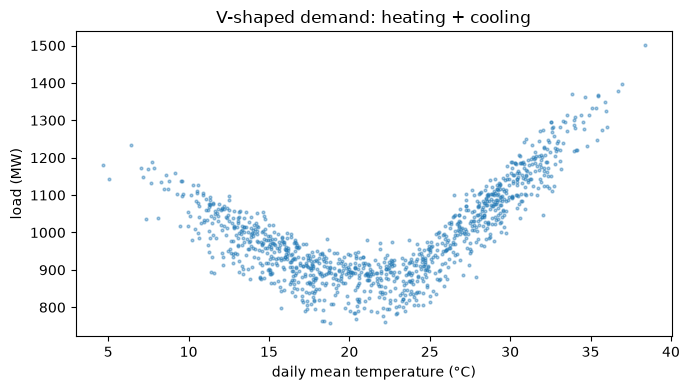

In [18]:
days = 3 * 365
T = 22 + 9 * np.sin(2 * np.pi * (np.arange(days) - 100) / 365) + rng.normal(0, 3, days)
weekend = (np.arange(days) % 7 >= 5).astype(int)
HDD, CDD = np.maximum(0, 18 - T), np.maximum(0, T - 24)
load = 900 + 25 * HDD + 40 * CDD - 80 * weekend + rng.normal(0, 30, days)     # MW
train, test = slice(0, 2 * 365), slice(2 * 365, days)                            # time-ordered split
designs = {"linear in T": np.c_[T, weekend], "degree-day features": np.c_[HDD, CDD, weekend]}
for name, F_ in designs.items():
    m_ = LinearRegression().fit(F_[train], load[train]); p_ = m_.predict(F_[test])
    mape = np.mean(np.abs(load[test] - p_) / load[test]) * 100
    print(f"{name:>20}: coef = {m_.coef_.round(1)}, test RMSE = {np.sqrt(np.mean((load[test] - p_)**2)):.1f} MW, MAPE = {mape:.2f}%")
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(T, load, s=4, alpha=0.4)
ax.set_xlabel("daily mean temperature (°C)"); ax.set_ylabel("load (MW)"); ax.set_title("V-shaped demand: heating + cooling")
plt.tight_layout(); plt.show()